In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
import pickle

In [5]:
class Dataset_converter(Dataset):
    def __init__(self, data, token_size, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), token_size), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, token_size*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), token_size))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*token_size:(kk+1)*token_size] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [6]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, token_size=7):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, nonlinearity='relu')
        self.fc1 = nn.Linear(hidden_size, token_size)
        
    def forward(self, x, hw=None, short_term_memory=None):
        if hw is None:
            out, hw = self.rnn(x)
        else:   
            out, hw = self.rnn(x, hw)
            
        out = self.fc1(out[:,-1,:])
        return out, hw


In [7]:
def wake_period(model, train_data, token_size, working_memory, short_term_memory, lr=4e-4):
    data_set = Dataset_converter(train_data, token_size, working_memory, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()

    total = 0
    correct_train = np.zeros(1000,dtype=float)
    train_acc = []
    for (X_train, y_train) in train_loader:
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = model(X_train, short_term_memory=short_term_memory)
        else:
            predicted_y, hidden = model(X_train, hw=memory, short_term_memory=short_term_memory)

        
        loss = criterion(predicted_y, y_train)
        loss.backward(retain_graph=True)
        optimizer.step()

        with torch.no_grad():
            memory = hidden.clone()
            true_y = y_train.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)

            total += 1
            if true_y == estimated_y:
                correct_train[total%1000] = 1
            else:
                correct_train[total%1000] = 0


            train_acc.append(
                np.sum(correct_train)/total if total<1000 else np.sum(correct_train)/1000
            )
            
            # if total%1000 == 0:
            #     print(f'Iter : {total+1}, loss: {loss:.4f}, train accuracy: {train_acc[-1]:.4f}, test accuracy: {test_acc[-1]:.4f}')

    return model, train_acc

In [15]:
nodes = list(range(5,45,5))
layers = [1,2,3,4]
reps = 10
lr = 4e-4
result_train = {}
result_test = {}

total_samples = 200000
working_memory = 1
short_term_memory = 7
n_community = 2
n_members = 3

token_size = n_community*n_members+1
input_size = token_size*working_memory

for layer in layers:
    print("Doing layer ", layer)
    result_train[layer] = {}
    result_test[layer] = {}
    for node in nodes:
        print("Doing Nodes ", node)
        result_train[layer][node] = []
        result_test[layer][node] = []
        for _ in tqdm(range(reps)):
            train_data = get_sequence(total_samples, n_community, n_members)
            model = RNN(input_size, node, num_layers=layer, token_size=token_size)
            _, train_acc = wake_period(model, train_data, token_size, working_memory, short_term_memory, lr=lr)
            result_train[layer][node].append(train_acc)


with open('pickle_files/minimal_rnn_changing_nodes_layers_relu.pickle', 'wb') as f:
    pickle.dump(result_train, f)

Doing layer  1
Doing Nodes  5


100%|██████████| 10/10 [11:32<00:00, 69.28s/it]


Doing Nodes  10


100%|██████████| 10/10 [11:27<00:00, 68.78s/it]


Doing Nodes  15


...

100%|██████████| 10/10 [29:24<00:00, 176.48s/it]


Doing Nodes  35


100%|██████████| 10/10 [29:25<00:00, 176.60s/it]


Doing Nodes  40


100%|██████████| 10/10 [29:27<00:00, 176.75s/it]


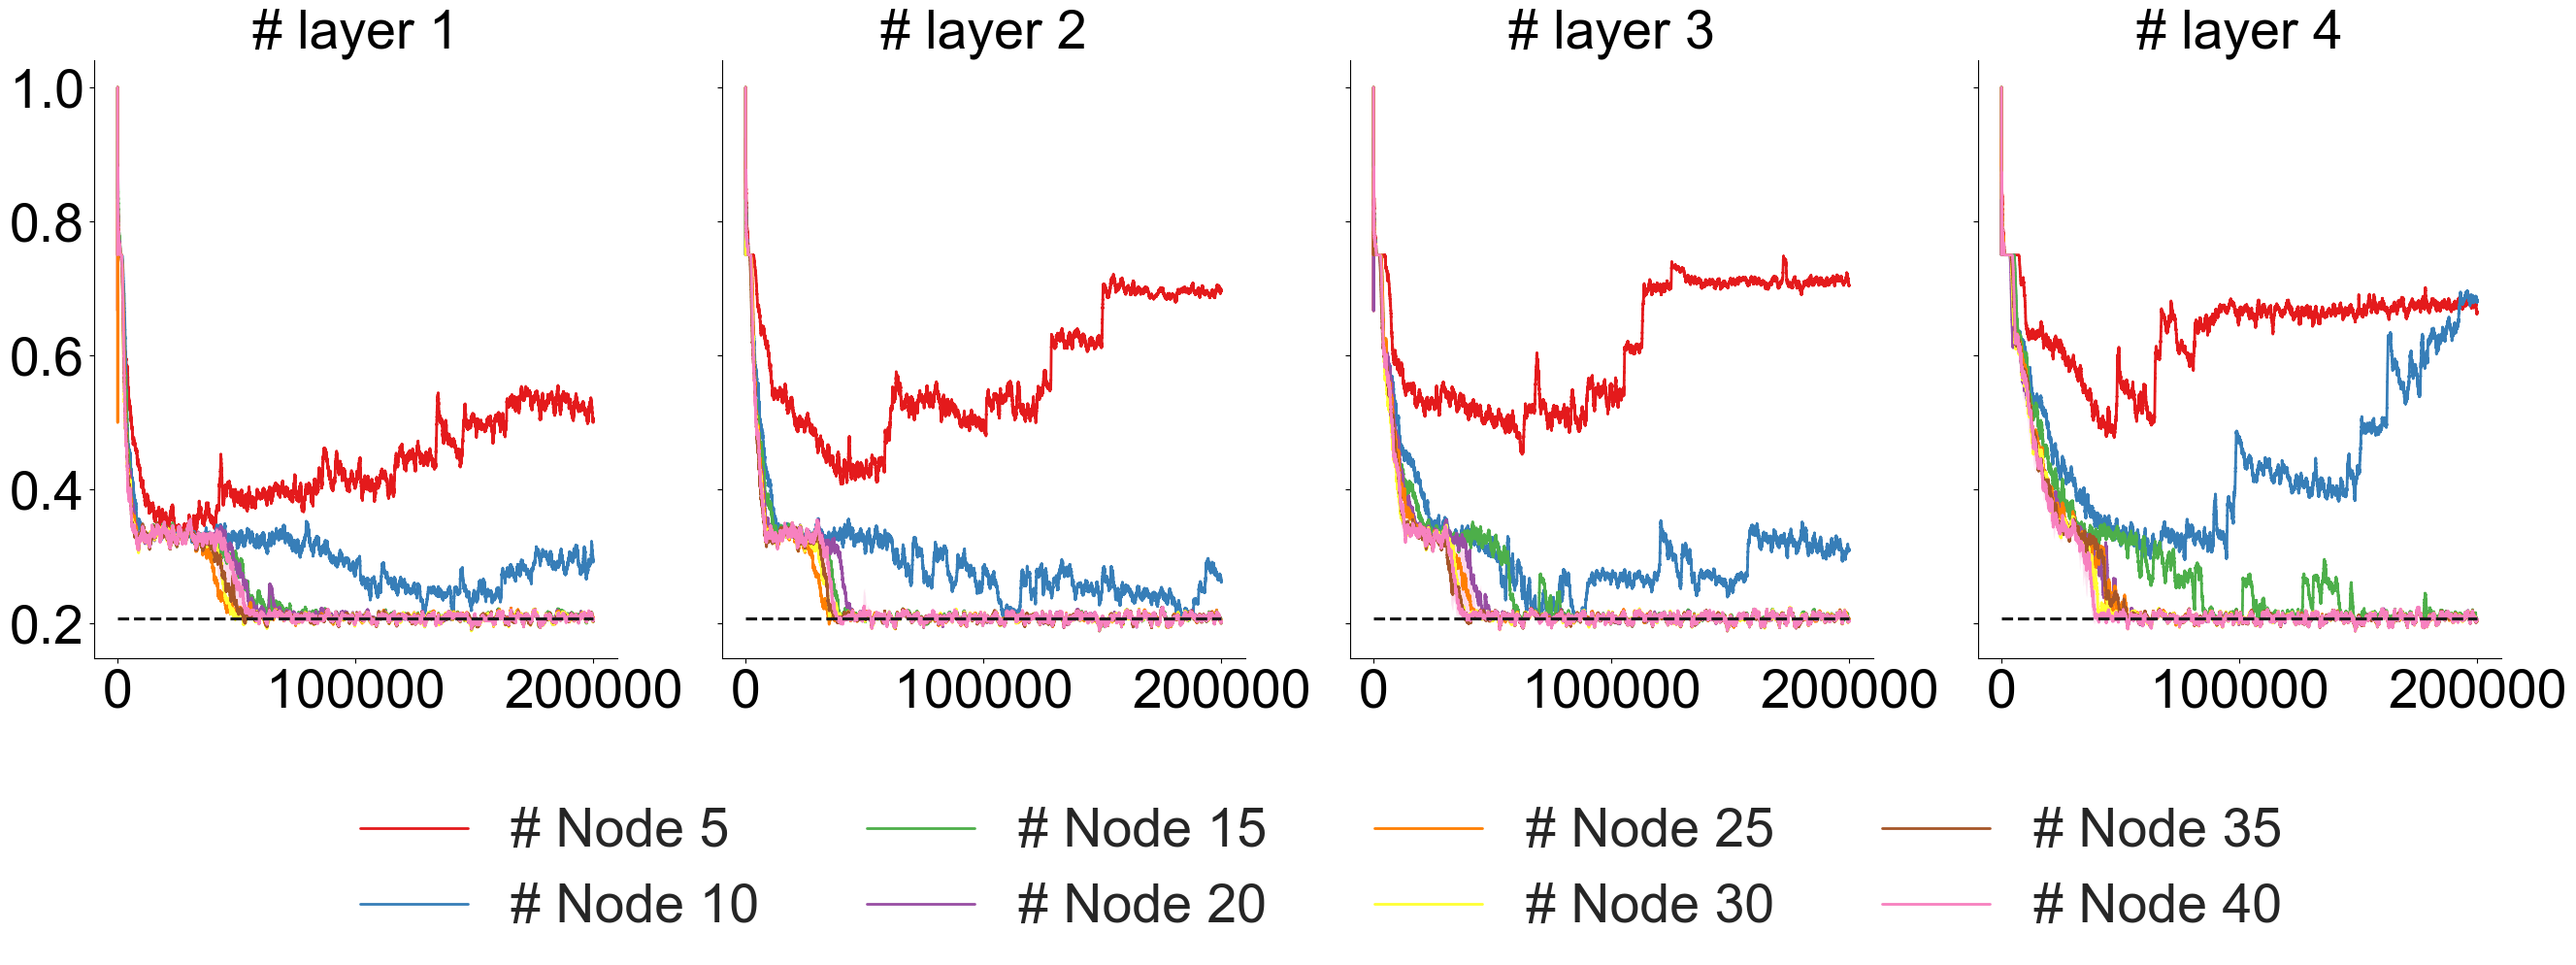

In [3]:
with open('pickle_files/minimal_rnn_changing_nodes_layers_relu.pickle', 'rb') as f:
    result_train = pickle.load(f)

fig, ax = plt.subplots(1, 4, figsize=(32,8), sharex=True, sharey=True)
nodes = list(range(5,45,5))
layers = [1,2,3,4]
total_samples = len(result_train[layers[0]][nodes[0]][0])
reps = 10
samples = list(range(1,total_samples+1))

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("Set1", n_colors=len(nodes))
font = 40
# samples_to_show = 10000

for ii, layer in enumerate(layers):
    res_train = []
    res_test = []
    for jj, node in enumerate(nodes):
        if ii==0:
            ax[ii].plot(samples, np.median(1-np.array(result_train[layer][node]),axis=0),linewidth=2, c=clr[jj], label='# Node '+str(node))
        else:
            ax[ii].plot(samples, np.median(1-np.array(result_train[layer][node]),axis=0),linewidth=2, c=clr[jj])
        

    ax[ii].hlines(1-(3.0+1/6.0)/4, 0, total_samples, linestyles='dashed', color='k')        
    ax[ii].fill_between(samples, np.quantile(1-np.array(result_train[layer][node]), 0.25, axis=0), np.quantile(1-np.array(result_train[layer][node]), 0.75, axis=0), facecolor=clr[jj], alpha=.3)

    ax[ii].tick_params(labelsize=font)

    ax[ii].set_title('# layer '+str(layer),fontsize=font)

 
    right_side = ax[ii].spines["right"]
    right_side.set_visible(False)
    top_side = ax[ii].spines["top"]
    top_side.set_visible(False)

    
#     ax[1][ii].hlines(1-(3.0+1/6)/4, 0, total_samples, linestyles='dashed', color='k')
#     ax[1][ii].tick_params(labelsize=40)

#     right_side = ax[1][ii].spines["right"]
#     right_side.set_visible(False)
#     top_side = ax[1][ii].spines["top"]
#     top_side.set_visible(False)

# ax[0][5].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', label='Optimal Performance', color='k')      
# ax[0][0].set_ylabel('Train Error', fontsize=font)
# ax[1][0].set_ylabel('Test Error', fontsize=font)
# #ax[1][3].set_xlabel('Samples Seen', fontsize=font+20)
# ax[0][0].set_yticks([0,.2,.4,1])
# ax[0][0].set_xticks([0,50000])

# fig.text(0.5,0,'Samples Seen',fontsize=font)
fig.legend(bbox_to_anchor=(0.52, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=4, loc='upper center', fontsize=font, frameon=False)

In [9]:
nodes = list(range(5,45,5))
layers = [1,2,3,4]
bptt = [1,3,5,7,9,11]
reps = 10
lr = 4e-4
result_train = {}

total_samples = 200000
working_memory = 1
# short_term_memory = 7
n_community = 2
n_members = 3

token_size = n_community*n_members+1
input_size = token_size*working_memory

for short_term_memory in bptt:
    print("Doing BPTT ", short_term_memory)
    result_train[short_term_memory] = {}
    for layer in layers:
        print("Doing layer ", layer)
        result_train[short_term_memory][layer] = {}
        for node in nodes:
            print("Doing Nodes ", node)
            result_train[short_term_memory][layer][node] = []
            for _ in tqdm(range(reps)):
                train_data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)
                model = RNN(input_size, node, num_layers=layer, token_size=token_size)
                _, train_acc = wake_period(model, train_data, token_size, working_memory, short_term_memory, lr=lr)
                result_train[short_term_memory][layer][node].append(train_acc)


with open('pickle_files/minimal_rnn_changing_nodes_layers_relu.pickle', 'wb') as f:
    pickle.dump(result_train, f)

Doing BPTT  1
Doing layer  1
Doing Nodes  5


100%|██████████| 10/10 [06:29<00:00, 38.94s/it]


Doing Nodes  10


100%|██████████| 10/10 [06:30<00:00, 39.07s/it]


Doing Nodes  15


...

100%|██████████| 10/10 [39:40<00:00, 238.07s/it]


Doing Nodes  35


100%|██████████| 10/10 [39:23<00:00, 236.36s/it]


Doing Nodes  40


100%|██████████| 10/10 [39:35<00:00, 237.58s/it]


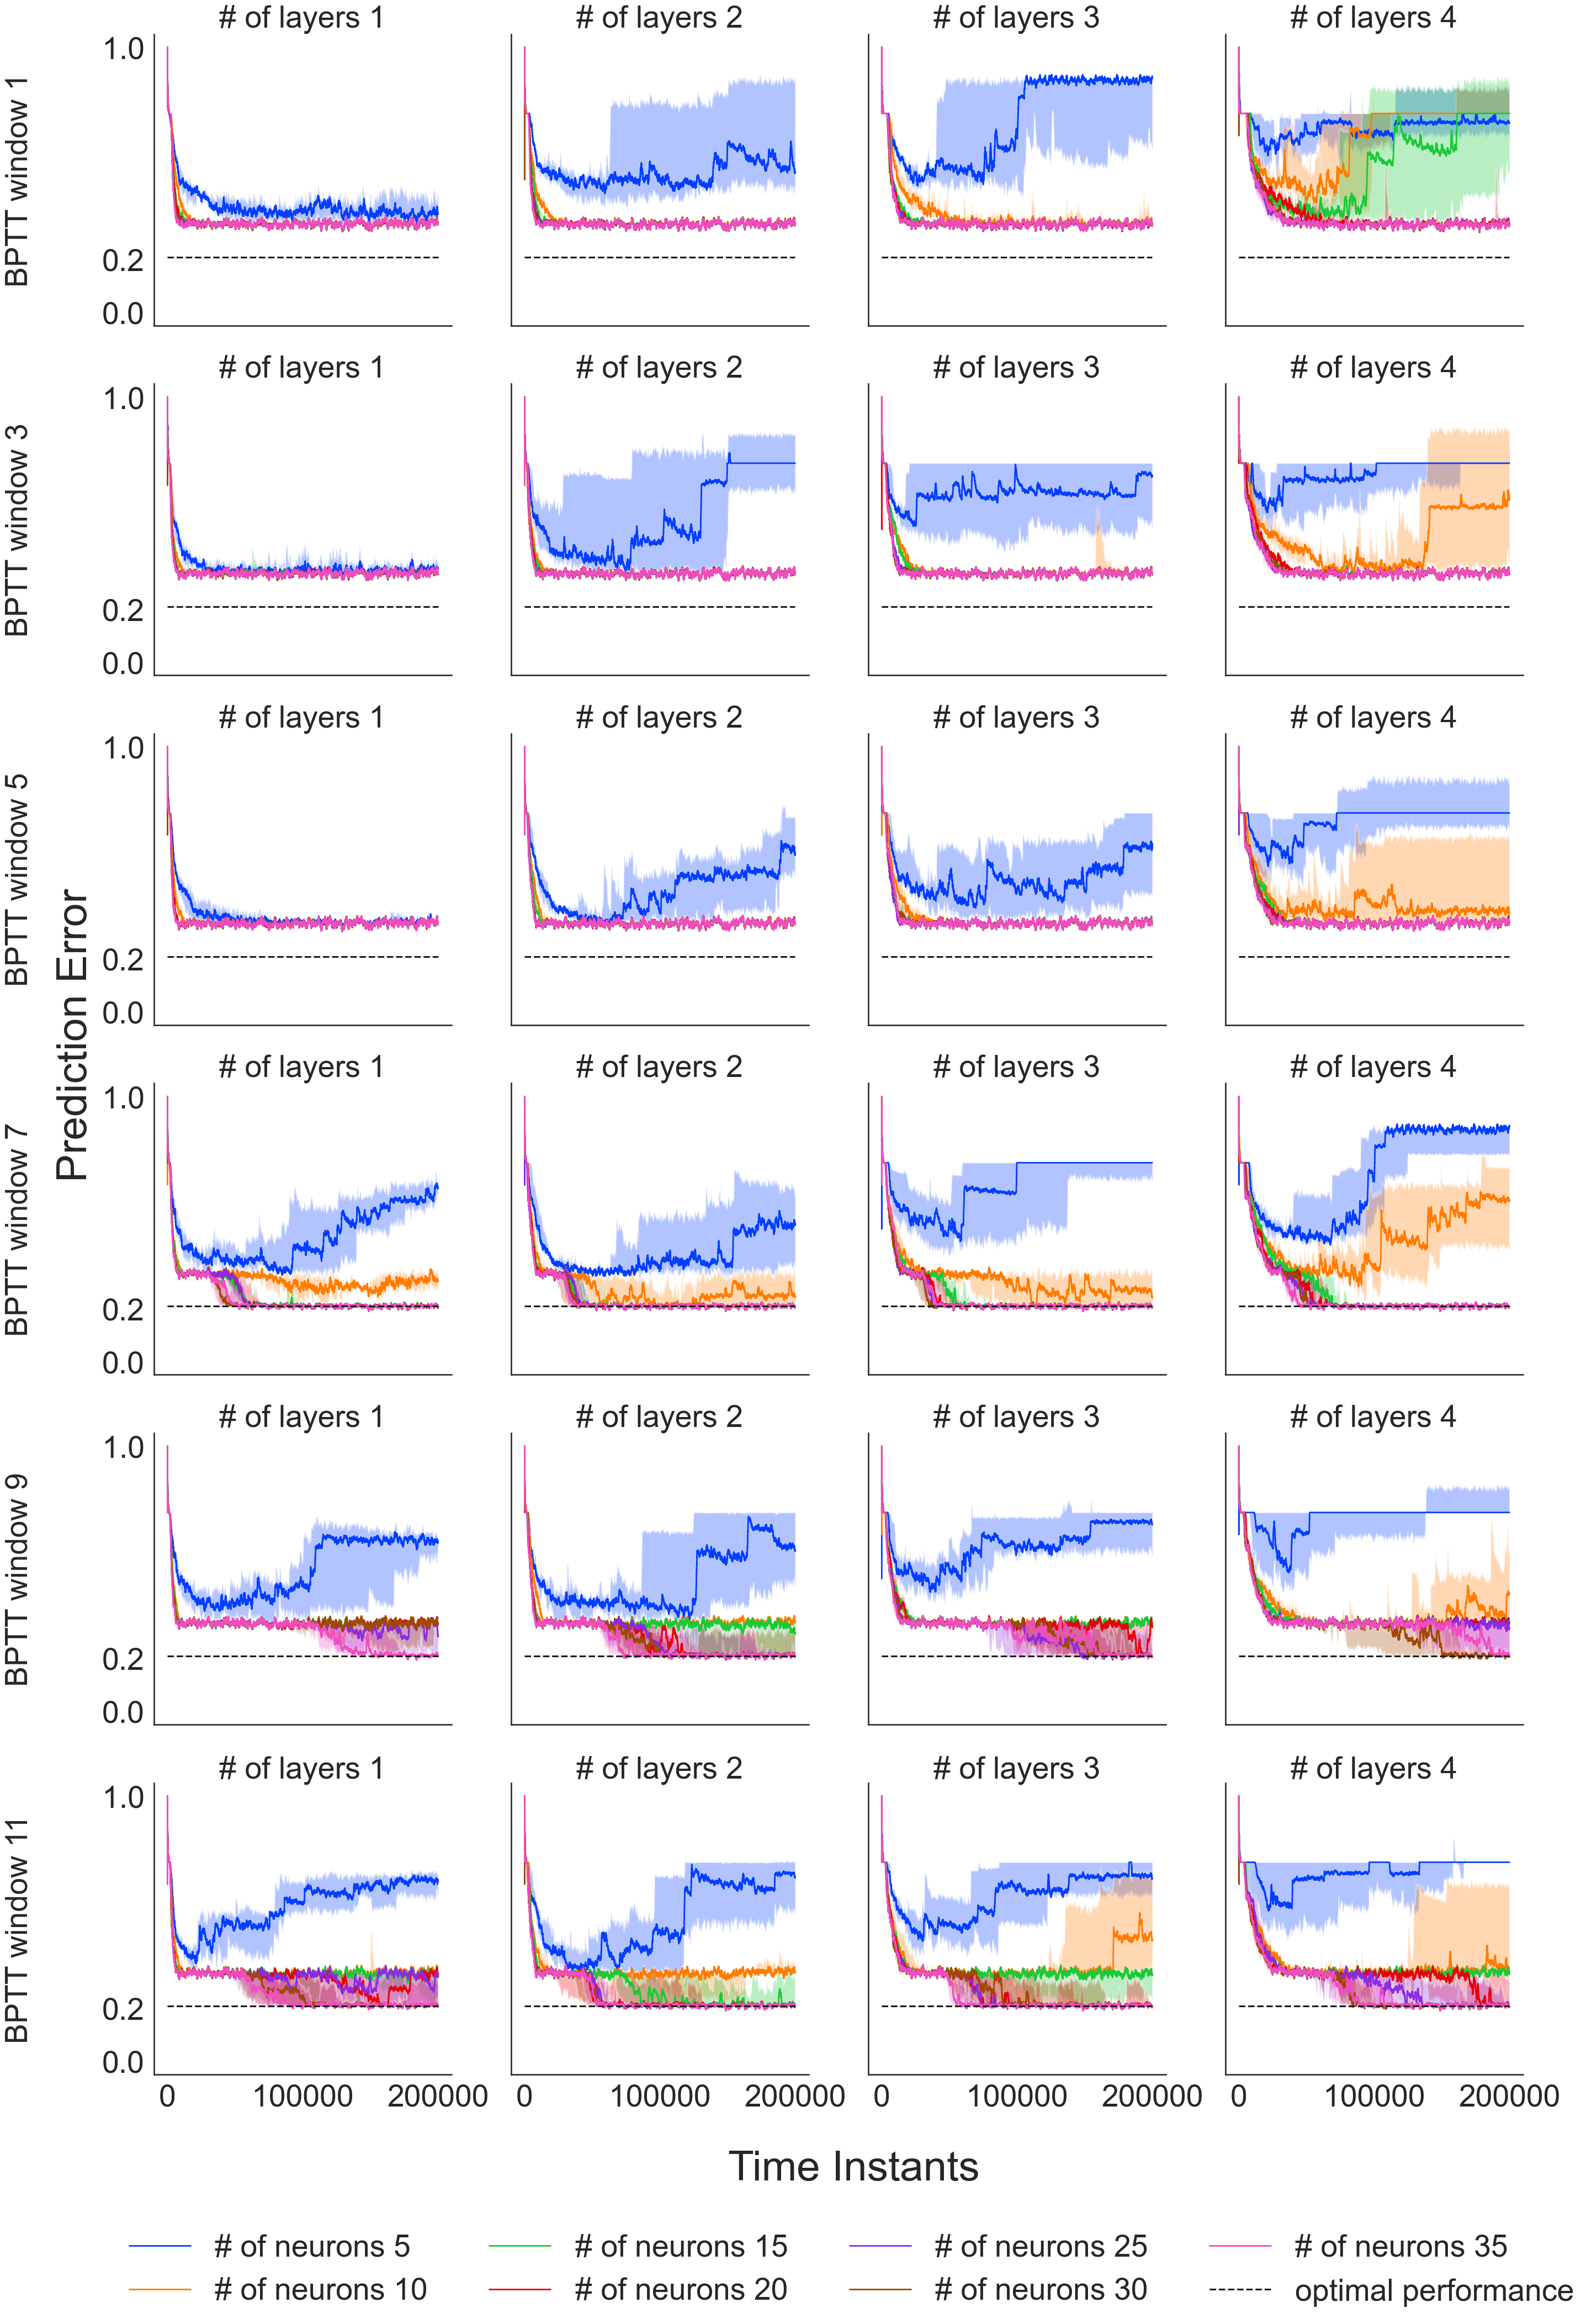

In [22]:
# with open('pickle_files/minimal_rnn_changing_nodes_layers_relu.pickle', 'rb') as f:
#     result_train = pickle.load(f)

nodes = list(range(5,40,5))
layers = [1,2,3,4]
bptt = [1,3,5,7,9,11]


fig, ax = plt.subplots(6, 4, figsize=(32,48), sharex=True, sharey=True)

reps = 10

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("bright", n_colors=len(nodes))
font = 40
# samples_to_show = 10000

for kk, win in enumerate(bptt):
    ax[kk][0].set_ylabel('BPTT window '+str(win)+'\n\n',fontsize=font)

    
    for ii, layer in enumerate(layers):

        # if win==bptt[-1]:
        #     ax[kk][ii].set_xlabel('Time Instants',fontsize=font)

        res_train = []
        res_test = []
        for jj, node in enumerate(nodes):
            total_samples = len(result_train[win][layer][node][0])
            samples = list(range(1,total_samples+1))
            if ii==0 and kk==0:
                ax[kk][ii].plot(samples, np.median(1-np.array(result_train[win][layer][node]),axis=0),linewidth=2, c=clr[jj], label='# of neurons '+str(node))
            else:
                ax[kk][ii].plot(samples, np.median(1-np.array(result_train[win][layer][node]),axis=0),linewidth=2, c=clr[jj])
            
            ax[kk][ii].fill_between(samples, np.quantile(1-np.array(result_train[win][layer][node]), 0.25, axis=0), np.quantile(1-np.array(result_train[win][layer][node]), 0.75, axis=0), facecolor=clr[jj], alpha=.3)

            
        if ii==0 and kk==0:
            ax[kk][ii].hlines(1-(3.0+1/6.0)/4, 0, total_samples, linestyles='dashed', color='k', label='optimal performance')
        else:
            ax[kk][ii].hlines(1-(3.0+1/6.0)/4, 0, total_samples, linestyles='dashed', color='k')

        
        ax[kk][ii].tick_params(labelsize=font)

        ax[kk][ii].set_title('# of layers '+str(layer),fontsize=font)
        ax[kk][ii].set_yticks([0,.2,1])
    
        right_side = ax[kk][ii].spines["right"]
        right_side.set_visible(False)
        top_side = ax[kk][ii].spines["top"]
        top_side.set_visible(False)

    
#     ax[1][ii].hlines(1-(3.0+1/6)/4, 0, total_samples, linestyles='dashed', color='k')
#     ax[1][ii].tick_params(labelsize=40)

#     right_side = ax[1][ii].spines["right"]
#     right_side.set_visible(False)
#     top_side = ax[1][ii].spines["top"]
#     top_side.set_visible(False)

# ax[0][5].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', label='Optimal Performance', color='k')      
# ax[0][0].set_ylabel('Train Error', fontsize=font)
# ax[1][0].set_ylabel('Test Error', fontsize=font)
# #ax[1][3].set_xlabel('Samples Seen', fontsize=font+20)
# ax[0][0].set_yticks([0,.2,.4,1])
# ax[0][0].set_xticks([0,50000])

fig.text(0.45,.07,'Time Instants',fontsize=font+15)
fig.text(0.07,.45,'Prediction Error',fontsize=font+15, rotation=90)
fig.legend(bbox_to_anchor=(0.52, 0.06), bbox_transform=plt.gcf().transFigure,
                        ncol=4, loc='upper center', fontsize=font, frameon=False)

plt.savefig('plots/minimal_RNN.png', bbox_inches='tight')